In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("marketing_AB.csv")

# Display the first 5 rows
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
# Check the number of rows and columns
df.shape

(588101, 7)

In [4]:
# Check column names, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [5]:
# Check for missing values
df.isnull().sum()

,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [6]:
# Check for duplicated user IDs
df["user id"].duplicated().sum()

np.int64(0)

In [7]:
df[df.astype(str).apply(lambda x: x.str.strip() == '').any(axis=1)]

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour


In [8]:
# Check the number of users in each test group
df["test group"].value_counts()

,count
test group,
ad,564577
psa,23524


In [9]:
# Check how many users converted
df["converted"].value_counts()

,count
converted,
False,573258
True,14843


In [10]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Convert user ID to string because it is an identifier
df["user id"] = df["user id"].astype(str)

# Check the cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  object
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 23.0+ MB


Exploratory Data Analysis

In [11]:
# Calculate the overall conversion rate
overall_conversion = df["converted"].mean() * 100

print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

Overall Conversion Rate: 2.52%


In [12]:
# Calculate conversion rate for each test group
conversion_by_group = df.groupby("test group")["converted"].mean() * 100

conversion_by_group

,converted
test group,
ad,2.554656
psa,1.785411


In [14]:
# Create conversion summary by test group
conversion_summary = df.groupby("test group").agg(
    Total_Users=("user id", "count"),
    Conversions=("converted", "sum"),
    Conversion_Rate=("converted", "mean")
)

# Convert conversion rate to percentage
conversion_summary["Conversion_Rate"] = (conversion_summary["Conversion_Rate"] * 100).round(2)

conversion_summary

,Total_Users,Conversions,Conversion_Rate
test group,,,
ad,564577,14423,2.55
psa,23524,420,1.79


In [15]:
# Get conversion rates for AD and PSA
ad_rate = conversion_summary.loc["ad", "Conversion_Rate"]
psa_rate = conversion_summary.loc["psa", "Conversion_Rate"]

# Calculate absolute difference and relative lift
absolute_difference = ad_rate - psa_rate
relative_lift = ((ad_rate - psa_rate) / psa_rate) * 100

print(f"Absolute Difference: {absolute_difference:.2f} percentage points")
print(f"Relative Lift: {relative_lift:.2f}%")

Absolute Difference: 0.76 percentage points
Relative Lift: 42.46%


Hypotheses

H₀: There is no significant difference in conversion rates between the AD and PSA groups.

H₁: There is a significant difference in conversion rates between the AD and PSA groups.

In [17]:
# Import the two-proportion Z-test
from statsmodels.stats.proportion import proportions_ztest

# Number of conversions in each group
conversions = [
    df.loc[df["test group"] == "ad", "converted"].sum(),
    df.loc[df["test group"] == "psa", "converted"].sum()
]

# Total number of users in each group
users = [
    (df["test group"] == "ad").sum(),
    (df["test group"] == "psa").sum()
]

# Perform two-proportion Z-test
z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users,
    alternative="two-sided"
)

print("Conversions:", conversions)
print("Users:", users)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Conversions: [np.int64(14423), np.int64(420)]
Users: [np.int64(564577), np.int64(23524)]
Z-statistic: 7.3701
P-value: 0.000000


In [18]:
# Calculate additional conversions per 10,000 users
incremental_conversions = (absolute_difference / 100) * 10000

print(f"Additional Conversions per 10,000 Users: {incremental_conversions:.0f}")

Additional Conversions per 10,000 Users: 76


In [19]:
# Calculate standard error for the difference in conversion rates
se = np.sqrt(
    (ad_rate / 100 * (1 - ad_rate / 100) / 564577) +
    (psa_rate / 100 * (1 - psa_rate / 100) / 23524)
)

# Calculate 95% confidence interval
lower = (absolute_difference / 100) - 1.96 * se
upper = (absolute_difference / 100) + 1.96 * se

# Convert to additional conversions per 10,000 users
lower_10000 = lower * 10000
upper_10000 = upper * 10000

print(f"95% Confidence Interval: {lower_10000:.0f} to {upper_10000:.0f} additional conversions per 10,000 users")

95% Confidence Interval: 59 to 93 additional conversions per 10,000 users


Conversion rate by day

In [20]:
# Calculate conversion rate by day
conversion_by_day = (
    df.groupby("most ads day")["converted"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

conversion_by_day

,converted
most ads day,
Monday,3.28
Tuesday,2.98
Wednesday,2.49
Sunday,2.45
Friday,2.22
Thursday,2.16
Saturday,2.11


In [26]:
# Calculate conversion rate by hour
conversion_by_hour = (
    df.groupby("most ads hour")["converted"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

conversion_by_hour

,converted
most ads hour,
16,3.08
20,2.98
15,2.97
21,2.89
17,2.82
14,2.81
18,2.74
19,2.67
22,2.61


AD conversion rate by day

In [22]:
# Filter only users who saw the advertisement
ad_group = df[df["test group"] == "ad"]

# Calculate AD conversion rate by day
ad_conversion_by_day = (
    ad_group.groupby("most ads day")["converted"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

ad_conversion_by_day

,converted
most ads day,
Monday,3.32
Tuesday,3.04
Wednesday,2.54
Sunday,2.46
Friday,2.25
Thursday,2.16
Saturday,2.13


AD conversion by hour

In [25]:
# Calculate AD conversion rate by hour
ad_conversion_by_hour = (
    ad_group.groupby("most ads hour")["converted"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

ad_conversion_by_hour

,converted
most ads hour,
16,3.09
20,3.03
15,2.98
21,2.92
14,2.86
17,2.85
18,2.75
19,2.68
22,2.65


Graph 1 — AD vs PSA

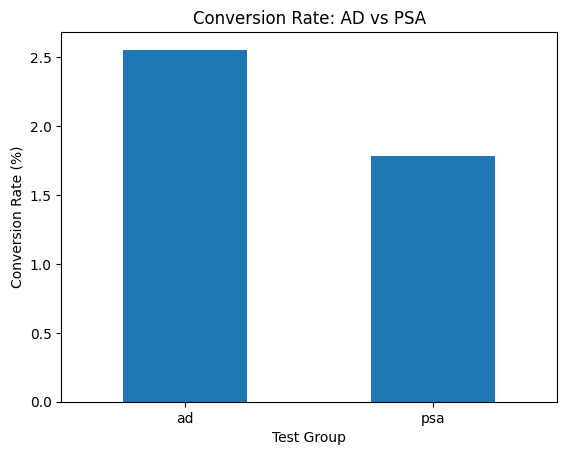

In [27]:
# Plot conversion rate for AD vs PSA
conversion_by_group.plot(kind="bar")

plt.title("Conversion Rate: AD vs PSA")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

Graph 2 — AD conversion rate by day.

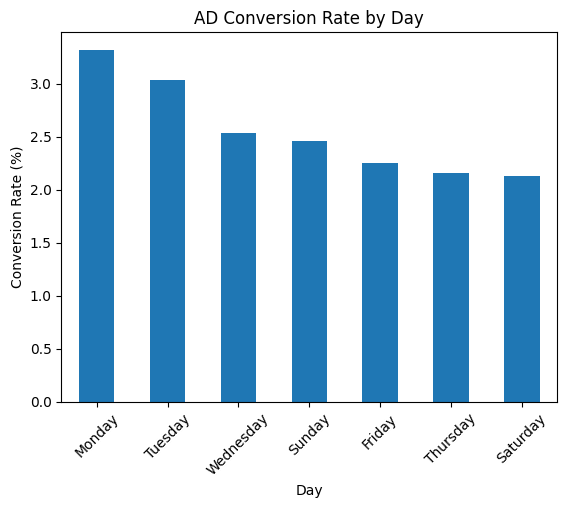

In [28]:
# Plot AD conversion rate by day
ad_conversion_by_day.plot(kind="bar")

plt.title("AD Conversion Rate by Day")
plt.xlabel("Day")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

Graph 3 — AD conversion rate by hour.

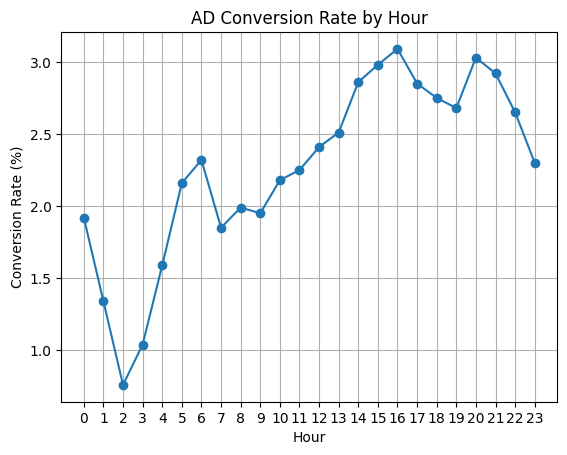

In [29]:
# Plot AD conversion rate by hour in chronological order
ad_conversion_by_hour.sort_index().plot(kind="line", marker="o")

plt.title("AD Conversion Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()